Class implementation for CAX simulation module

```26/05/2026```

What do I need to accomplish? I need to be able to simulate the passage of light through the CAX beamline, from source through slits to DVF screen. I then need to be able to extract the resulting image at a given $y$ position (optical axis). Then I need to perform movements to the mirror and regenerate the image.

To create a general `CAXSim` class, I'll first write a basic `OpticalElement` wrapper class for Shadow OEs, then I'll create children with more specific methods, all the way to a `BeamLine` class that possesses the necessary attributes and methods to perform simulations and modify the system. 

In [1]:
!which python

/home/amici/miniconda3/bin/python


In [2]:
import os
import sys

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/cax-control"))


In [3]:
from shadowpy.cax_simulation import CAXSim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
cax = CAXSim(total_rays=500000)

/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


Traced through element 1: M1
Traced through element 2: DVF_A1
Traced through element 3: DVF_B1


Traced through element 1: M1
Traced through element 2: DVF_A1
Traced through element 3: DVF_B1


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


Minimum FWHM X: 46.61 μm at distance -117.24 mm
Minimum FWHM Y: 26.85 μm at distance -127.59 mm
Traced through element 1: M1


...

Traced through element 2: DVF_A1
Traced through element 3: DVF_B1
Minimum FWHM X: 46.60 μm at distance -124.14 mm
Minimum FWHM Y: 26.85 μm at distance -122.41 mm
Traced through element 1: M1
Traced through element 2: DVF_A1
Traced through element 3: DVF_B1
Minimum FWHM X: 46.59 μm at distance -124.14 mm
Minimum FWHM Y: 26.86 μm at distance -118.97 mm
Traced through element 1: M1
Traced through element 2: DVF_A1
Traced through element 3: DVF_B1


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


Traced through element 1: M1


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


Traced through element 2: DVF_A1
Traced through element 3: DVF_B1


In [59]:
cax.mirror.ry = -0.0009

In [69]:
cax.mirror.ry = 0


In [70]:
dist, fwhm_x, fwhm_y = cax.dvf_B1.simple_caustic(cax.dvf_B1.beam, 
                                                    (-300, 0),
                                                    n_points=60)

In [51]:
cax.source.shadow_oe.SIGMAZ

0.0115

(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

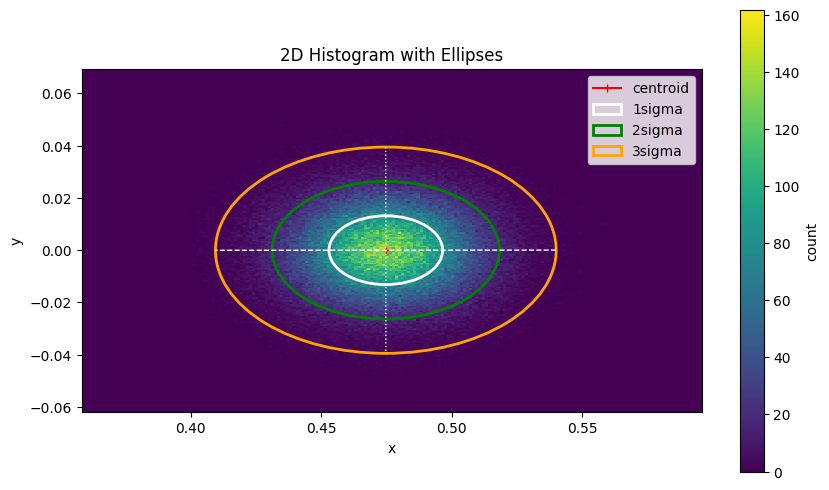

In [56]:
cax.dvf_B1.image.plot()

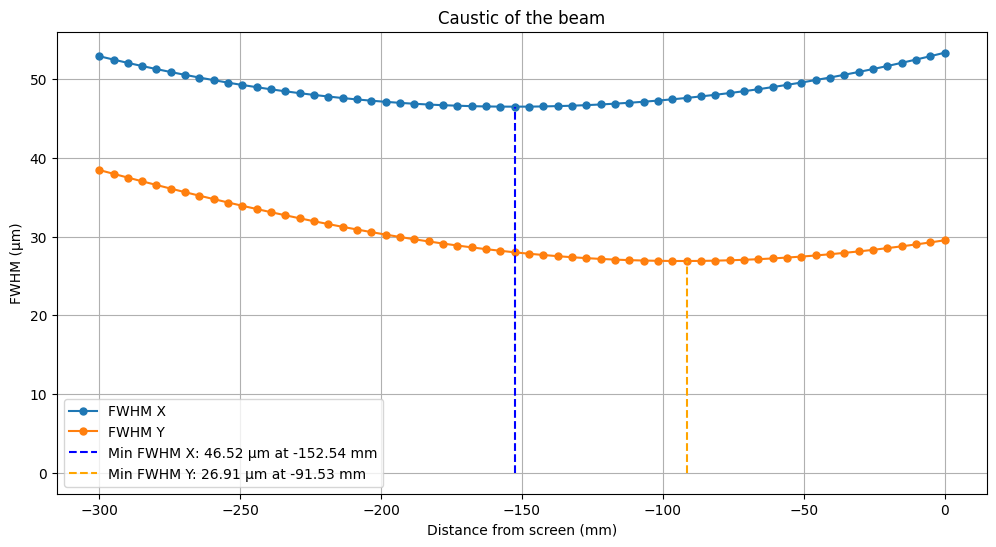

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(dist, 1000*fwhm_x, marker='o', markersize=5, label="FWHM X")
plt.plot(dist, 1000*fwhm_y, marker='o', markersize=5, label="FWHM Y")
plt.vlines(dist[np.argmin(fwhm_x)], 0, 1000*np.min(fwhm_x), color='blue', linestyle='--', label=f"Min FWHM X: {1000*np.min(fwhm_x):.2f} μm at {dist[np.argmin(fwhm_x)]:.2f} mm")
plt.vlines(dist[np.argmin(fwhm_y)], 0, 1000*np.min(fwhm_y), color='orange', linestyle='--', label=f"Min FWHM Y: {1000*np.min(fwhm_y):.2f} μm at {dist[np.argmin(fwhm_y)]:.2f} mm")
plt.xlabel('Distance from screen (mm)')
plt.ylabel('FWHM (μm)')
plt.title('Caustic of the beam')
plt.legend()
plt.grid()


In [58]:
print(f"Minimum FWHM X: {1000*np.min(fwhm_x):.2f} μm at distance {dist[np.argmin(fwhm_x)]:.2f} mm")
print(f"Minimum FWHM Y: {1000*np.min(fwhm_y):.2f} μm at distance {dist[np.argmin(fwhm_y)]:.2f} mm") 

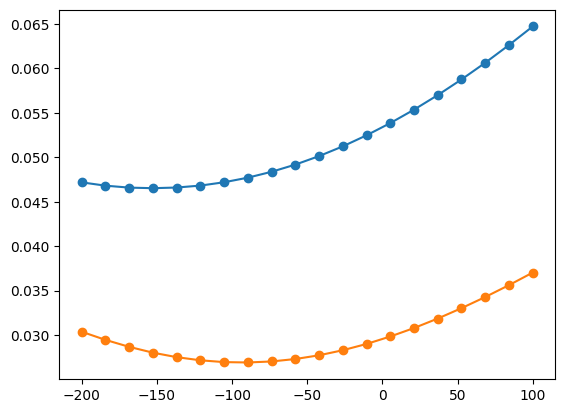

In [8]:
plt.plot(dist, fwhm_x, marker='o', label="FWHM X")
plt.plot(dist, fwhm_y, marker='o', label="FWHM Y")

In [13]:
cax.mirror.frame

ReferenceFrame(name=M1_frame, origin=[0.00000000e+00 1.04094978e-12 1.70000000e+04])

In [8]:
cax.mirror.ry = 0.01

(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

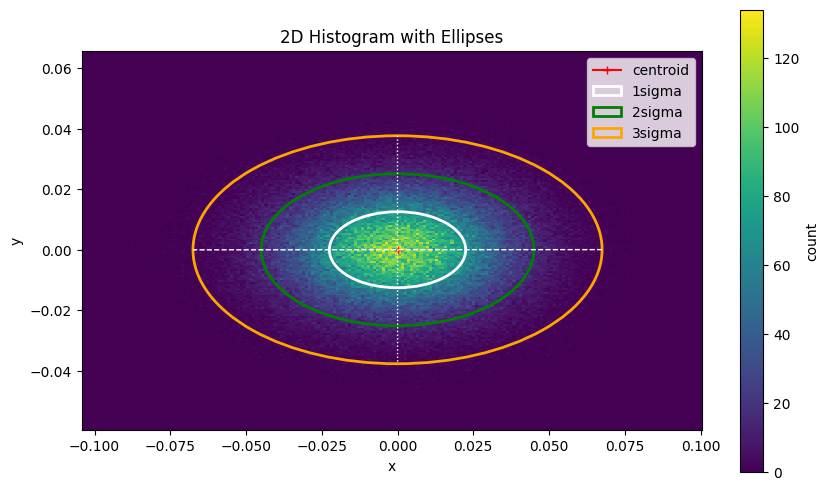

In [38]:
cax.dvf_B1.image.plot()

In [14]:
cax.dvf_B1.image.print_stats()

In [ ]:
cax.dvf_B1.image.plot()

In [ ]:
print("HELOOOOO")

In [ ]:
import Shadow
from shadowpy.optical_elements import ToroidalMirror, Slits, Screen
from shadowpy.sources import BendingMagnet
from shadowpy.beamline import BeamLine
from shadowpy.utils import rotation_matrix, ReferenceFrame
# from optlnls.shadow import run_shadow_caustic, get_good_ranges, read_caustic, plot_caustic

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
source = BendingMagnet("B1", "../specs/source.txt")


In [ ]:
cax.beam.rays.shape

In [ ]:
source.shadow_oe

In [ ]:
# CAX Optical Elements
source = BendingMagnet("B1", "source.props")
mirror = ToroidalMirror("M1", "mirror.props")
slit   = Slits("Slit_A1", "slits.props")
screen = Screen("DVF_B1", "screen.props")

optical_elements = [mirror, slit, screen]

# Frames of reference
sirius_frame = ReferenceFrame(name="sirius")

R1 = rotation_matrix('x', 90)
R2 = rotation_matrix('y', 180)
source_R = R1 @ R2

shadow_frame = sirius_frame.child_frame(relative_origin=[0, 0, 0], 
                                        relative_rotation=source_R, 
                                        name="shadow")

beam = Shadow.Beam()
cax  = BeamLine(name="CAX", source=source, optical_elements=optical_elements,
               beamline_frame=shadow_frame, lab_frame=sirius_frame, beam=beam)

In [ ]:
cax.trace()

In [ ]:
screen.image.plot()

In [ ]:
screen.image.hprm_momenta

In [ ]:
focus = cax.beams[-1]
x = screen.image.xcenters
y = screen.image.ycenters

beam2D = np.zeros((len(y)+1, len(x)+1))
beam2D[0,1:] = x
beam2D[1:,0] = y
beam2D[1:,1:] = screen.image.img


In [ ]:
from optlnls.shadow

In [ ]:
from optlnls.plot import plot_beam

plot_beam(beam2D, cut=3, textA=1, textB=5, textC=10, textD=0, fitType=1,
          x_range=1, y_range=1, plot_title='CAX M1 Ry=0.1 urad', show_colorbar=1,
          x_range_min=-0.12, x_range_max=0.12, y_range_min=-0.12, y_range_max=0.12,
          zero_pad_x=1, zero_pad_y=1, cmap='viridis', integral=1e11,
          units=2)


In [ ]:
screen.image.plot()

In [ ]:
source.image.print_stats(hprm=source.image.hprm_fit)

In [ ]:
screen.image.print_stats(hprm=screen.image.hprm_fit)

In [ ]:
fig, ax = plt.subplots()
fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, fig=fig, ax=ax)
ax.set_xlabel("Horizontal position (mm)")
ax.set_ylabel("Vertical position (mm)")
ax.set_title("Beam profile at screen")
# plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
mirror.offset

In [ ]:
mirror.offset = [1, 0, 0]

In [ ]:
# tx scan
tx = np.linspace(-3, 3, 11)
fwhm_x = np.array([])
fwhm_y = np.array([])

In [ ]:
ry = np.linspace(2, 3, 11)*1e-3 #mrad
fwhm_x = np.array([])
fwhm_y = np.array([])
mu_x   = np.array([])
mu_y   = np.array([])

In [ ]:
for ry_i in ry:
    mirror.tilt = [0, ry_i, 0]
    ax.clear()
    
    fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, colorbar=False, fig=fig, ax=ax)
    np.append(fwhm_x, screen.image.hprm_fit['fwhmx'])
    np.append(fwhm_y, screen.image.hprm_fit['fwhmy'])
    np.append(mu_x, screen.image.hprm_fit['mux'])
    np.append(mu_y, screen.image.hprm_fit['muy'])
    # ax.set_xlim(-0.1, 0.1)
    # ax.set_ylim(-0.06, 0.06)
    clear_output(wait=True)
    display(fig)

In [ ]:
mirror.offset = np.array([-0.20977, -1.90443, 0])
mirror.tilt = np.array([-2.04134, 1.56847, 4.26974])*1.e-3

In [ ]:
screen.image.plot()

In [ ]:
# nelder-mead

In [ ]:
ry

In [ ]:
for tx_i in tx:
    mirror.offset = [tx_i, 0, 0]
    ax.clear()
    
    fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, colorbar=False, fig=fig, ax=ax)
    fwhm_x.append(screen.image.hprm_fit['fwhmx'])
    fwhm_y.append(screen.image.hprm_fit['fwhmy'])
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.06, 0.06)
    clear_output(wait=True)
    display(fig)

In [ ]:
plt.ioff()

In [ ]:
plt.plot(tx, fwhm_x, label='FWHM X')
plt.plot(tx, fwhm_y, label='FWHM Y')
plt.xlabel('Mirror Tx (mm)')
plt.ylabel('FWHM (μm)')
plt.title('FWHM vs Mirror Tx')
# plt.ylim(0.025, 0.03)
plt.legend()
plt.show()

In [ ]:
plt.show()

In [ ]:
plt.ion()

fig, ax = plt.subplots()
fig, ax = screen.image.plot(hprm=screen.image.hprm_fit, fig=fig, ax=ax)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
print(f"Horizontal FWHM: \t{screen.image['fwhm_h']*1000:.6f} μm")
print(f"Vertical FWHM:   \t{screen.image['fwhm_v']*1000:.6f} μm")

In [ ]:
screen.shadow_oe.IDUMMY

In [ ]:
screen.reset()

In [ ]:
mirror.offset

In [ ]:
mirror.offset = [1.4, 0, 0]

In [ ]:
mirror.offset

In [ ]:
mirror.image

In [ ]:
len(cax.beams)

In [ ]:
Shadow.ShadowTools.plotxy(cax.beams[3],1,3,nbins=100, nolost=1,title="Real space")


In [ ]:
Shadow.ShadowTools.plotxy(cax.beams[3],1,3,nbins=101,nolost=1,title="Real space")


In [15]:
test_beam = cax.beams[3].duplicate()

In [ ]:
Shadow.ShadowTools.plotxy(test_beam,1,3,nbins=101,nolost=1,title="Real space")


In [16]:
retraced_beam = test_beam.duplicate()

In [ ]:
retraced_beam.retrace(0)

In [ ]:
Shadow.ShadowTools.plotxy(retraced_beam,1,3,nbins=101,nolost=1,title="Real space")

In [ ]:
import numpy as np

In [ ]:
screen.image["histogram"].shape

In [99]:
cax = CAXSim(total_rays=1000000)

In [5]:
cax.mirror.ry = -0.001#-0.01

In [6]:
# Caustic
fwhm_x = []
fwhm_y = []
retraced_beam = cax.beams[3].duplicate()
distances = np.linspace(-400, 100, 50)
for dist in distances:
    retraced_beam.retrace(dist)
    ticket = retraced_beam.histo2(col_h=3, col_v=1, nbins=150, nolost=1)
    fwhm_x.append(ticket['fwhm_h'])
    fwhm_y.append(ticket['fwhm_v'])



(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

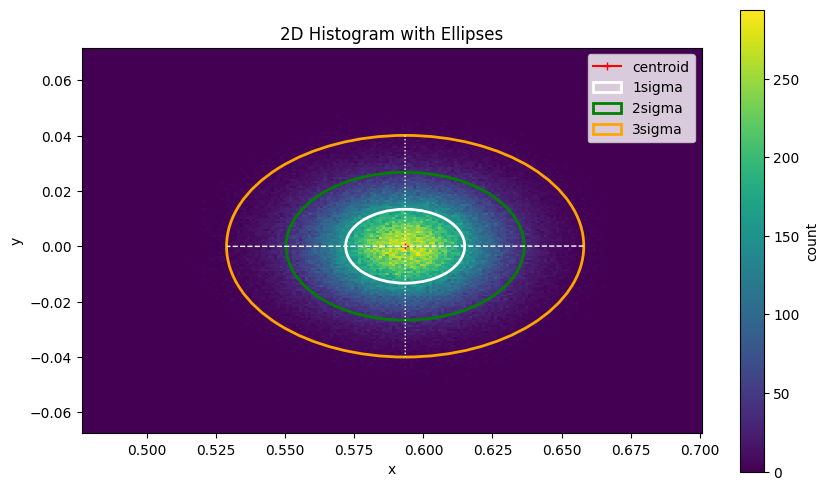

In [109]:
cax.dvf_B1.image.plot()

In [115]:
cax.dvf_B1.image.print_stats()

In [113]:
cax.dvf_B1.tz = -104
cax.dvf_B1.tx = 0

In [8]:
from scipy.signal import savgol_filter

In [9]:
fhwm_x_smooth = savgol_filter(fwhm_x, 11, 3)
fhwm_y_smooth = savgol_filter(fwhm_y, 11, 3)


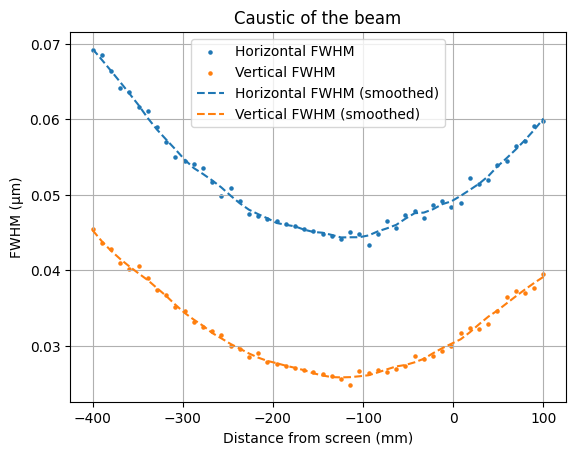

In [17]:
plt.scatter(distances, np.array(fwhm_x), s=5, label='Horizontal FWHM')
plt.scatter(distances, np.array(fwhm_y), s=5, label='Vertical FWHM')

plt.plot(distances, fhwm_x_smooth, label='Horizontal FWHM (smoothed)', linestyle='--')
plt.plot(distances, fhwm_y_smooth, label='Vertical FWHM (smoothed)', linestyle='--')

plt.xlabel('Distance from screen (mm)')
plt.ylabel('FWHM (μm)')
plt.title('Caustic of the beam')
plt.legend()
plt.grid()
plt.show()

In [107]:
np.argmin(fwhm_x), np.argmin(fwhm_y)

(29, 29)

In [108]:
distances[np.argmin(fwhm_x)], distances[np.argmin(fwhm_y)]

(-104.0816326530612, -104.0816326530612)

In [ ]:
screen.shadow_oe.OFFY = -100

In [ ]:
screen.offset

In [ ]:
import sys
import os

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/dev_packages/siriuspy/siriuspy"))


In [ ]:
from caxscripts.image_statistics import Histogram2DAnalyzer

In [ ]:
ticket = screen.image
hist = ticket["histogram"]
bin_h_edges = ticket["bin_h_edges"]
bin_v_edges = ticket["bin_v_edges"]

ana = Histogram2DAnalyzer(img=hist, xedges=bin_h_edges, yedges=bin_v_edges)
ana.fit()

In [ ]:
ana.plot(hprm=ana.hprm_fit)

In [ ]:
ana.compute_quick()

In [ ]:
cx, cy = ana._qck_centroid()

droi = 4
img = ana.img
roi_avg = np.mean(img[cx - droi:cx + droi, cy - droi:cy + droi]
)
mean = np.mean(img)
ratio = roi_avg / mean if mean != 0 else 0
ratio >= 10

In [ ]:
roi_avg

In [ ]:
mean

In [ ]:
ratio

In [ ]:
cx

In [ ]:
roi_avg

In [ ]:
ana.hprm_mom['fwhmy']

In [ ]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [ ]:
cax.beam.retrace(12641)

In [ ]:
Shadow.ShadowTools.plotxy(cax.beam,1,3,nbins=101,nolost=1,title="Real space")


In [ ]:
cax.elements[1].frame

In [ ]:
mirror.offset

In [ ]:
mirror.offset = [0.1, 0.2, 0.3]

In [ ]:
source_x_vec = np.array([1, 0, 0])
source_y_vec = np.array([0, 1, 0])
source_z_vec = np.array([0, 0, 1])


In [ ]:
shadow_source_frame.vector_to_lab(source_z_vec)

In [ ]:
mirror_R = rot_matrix('y', -np.pi/2)

In [ ]:
shadow_mirror_frame = shadow_source_frame.child_frame(relative_origin=[0, 17000, 0],
                                                      relative_rotation=mirror_R,
                                                      name="shadow_mirror")

In [ ]:
mirror_x_vec = np.eye(3)[0]
mirror_y_vec = np.eye(3)[1]
mirror_z_vec = np.eye(3)[2]


In [ ]:
print(f"Mirror X vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_x_vec))}")
print(f"Mirror Y vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_y_vec))}")
print(f"Mirror Z vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_z_vec))}")

In [ ]:
shadow_screens_frame = shadow_mirror_frame.child_frame(relative_origin=[0, 4359, 0],
                                                      relative_rotation=np.eye(3),
                                                      name="shadow_screen")

In [ ]:
np.round(shadow_screens_frame.point_to_lab(shadow_screens_frame.origin)[2]+12641)